## ROGUE Purity Audit — Reference Cell Type Annotations

Computes ROGUE purity for each `global.cluster4` label on the full transcriptome. These labels are the GSEA gene sets used in notebook 1 — if a label is impure, GEPs assigned to it may reflect a sub-state, not the whole label.

**Reference:** Liu et al., *Nat Commun* (2020). https://github.com/PaulingLiu/ROGUE

In [1]:
import os
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import sparse
import time
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

import rpy2.robjects as ro
from rpy2.robjects import pandas2ri, numpy2ri
from rpy2.robjects.packages import importr

CONVERTER = ro.default_converter + pandas2ri.converter + numpy2ri.converter

rogue_r = importr('ROGUE')
tibble  = importr('tibble')

#### 1. Configuration

Match these to your existing GSEA notebook + point at the raw-count AnnData.

In [ ]:
# raw-count AnnData (same one used as cNMF input)
ADATA_PATH = "hnc_data/hnc_myeloid_2021.h5ad"
COUNTS_LAYER = None  # set to a layer name if counts aren't in .X; else .X is used

# metadata
METADATA_PATH = "hnc_data/hnc_myeloid_globalcluster4.csv"
BARCODE_COL   = None
CELLTYPE_COL  = "global.cluster4"
METADATA_SEP  = ","

# ROGUE params
ROGUE_PLATFORM = "UMI"   # 'UMI' (=droplet) or 'full-length'
ROGUE_K        = 45      # 45 for UMI, 500 for full-length; reference factor (NOT cNMF K)
MIN_CELLS_PER_GROUP = 15

OUT_DIR = "rogue_purity_results_celltype"
os.makedirs(OUT_DIR, exist_ok=True)
print("Configuration loaded.")

Configuration loaded.


#### 2. Load raw counts + metadata

In [3]:
adata = sc.read_h5ad(ADATA_PATH)
print(f"AnnData: {adata.shape}")

# ROGUE expects genes x cells, raw counts
X = adata.layers[COUNTS_LAYER] if COUNTS_LAYER else adata.X
if sparse.issparse(X):
    X = X.toarray()
X = X.astype(np.float64)

if not np.allclose(X, np.round(X)):
    raise ValueError("Matrix doesn't look like raw counts — check COUNTS_LAYER.")

counts_df = pd.DataFrame(X.T, index=adata.var_names, columns=adata.obs_names)
print(f"Counts matrix (genes × cells): {counts_df.shape}")

meta = pd.read_csv(METADATA_PATH, sep=METADATA_SEP,
                   index_col=0 if BARCODE_COL is None else None)
if BARCODE_COL is not None:
    meta = meta.set_index(BARCODE_COL)
meta.index = meta.index.astype(str)

common = counts_df.columns.intersection(meta.index)
counts_df = counts_df[common]
meta = meta.loc[common]
meta['orig.ident'] = adata.obs.loc[meta.index, 'orig.ident'].astype(str)
print(f"Aligned to {len(common)} cells")

AnnData: (26444, 23630)
Counts matrix (genes × cells): (23630, 26444)
Aligned to 26444 cells


#### 3. ROGUE wrapper

Runs ROGUE per (sample, cluster) pair and returns the results as a long DataFrame (one row per pair) plus a samples × clusters pivot.

In [4]:
def compute_rogue(counts_df, labels, samples=None,
                  platform=ROGUE_PLATFORM, k=ROGUE_K,
                  min_cells=MIN_CELLS_PER_GROUP, verbose=True):
    """
    counts_df : DataFrame (genes × cells), raw counts
    labels    : Series indexed by cell barcode → cluster label
    samples   : Series indexed by cell barcode → sample/patient ID, or None
    Returns   : (long DataFrame [sample, cluster, ROGUE, n_cells],
                 wide DataFrame [samples × clusters])
    """
    label_counts = labels.value_counts()
    keep = label_counts[label_counts >= min_cells].index
    dropped = sorted(set(label_counts.index) - set(keep))
    if dropped and verbose:
        print(f"Skipping {len(dropped)} cluster(s) below {min_cells} cells: {dropped}")

    cells = labels[labels.isin(keep)].index
    counts_sub = counts_df[cells]
    labels_sub = labels.loc[cells].astype(str)
    samples_sub = (pd.Series("all", index=cells) if samples is None
                   else samples.loc[cells].astype(str))

    pairs = (pd.DataFrame({'sample': samples_sub.values, 'cluster': labels_sub.values})
               .value_counts()
               .reset_index(name='n_cells'))
    pairs = pairs[pairs['n_cells'] >= min_cells].reset_index(drop=True)

    if verbose:
        print(f"Counts: {counts_sub.shape[0]:,} genes × {counts_sub.shape[1]:,} cells")
        print(f"Computing ROGUE for {len(pairs)} (sample, cluster) pair(s)")
        for _, r in pairs.iterrows():
            print(f"  {r['sample']} / {r['cluster']}: {r['n_cells']} cells")
        print()

    # push counts to R once; subset per (sample, cluster) inside the loop
    with CONVERTER.context():
        ro.globalenv['expr_full'] = counts_sub
    ro.r('''
        suppressMessages(library(ROGUE))
        expr_full <- as.matrix(expr_full)
    ''')

    results = []
    t_total = time.time()
    iterator = tqdm(list(pairs.itertuples(index=False)),
                    total=len(pairs), disable=not verbose,
                    desc="ROGUE")

    for row in iterator:
        s, ct, n = row.sample, row.cluster, row.n_cells
        in_mask = (samples_sub == s) & (labels_sub == ct)
        sub_cells = labels_sub.index[in_mask].tolist()

        with CONVERTER.context():
            ro.globalenv['cells_keep'] = ro.StrVector(sub_cells)

        t0 = time.time()
        try:
            ro.r(f'''
                expr_mat  <- expr_full[, cells_keep, drop=FALSE]
                expr_mat  <- matr.filter(expr_mat, min.cells = 10, min.genes = 10)
                ent_res   <- SE_fun(expr_mat, span = 0.6, mt.method = "fdr")
                rogue_val <- CalculateRogue(ent_res, platform = "{platform}", k = {k})
            ''')
            with CONVERTER.context():
                rogue_val = float(ro.r('rogue_val')[0])
            ok = True
        except Exception as e:
            rogue_val = float('nan')
            ok = False
            if verbose:
                tqdm.write(f"  ✗ {s} / {ct}: FAILED — {e}")

        elapsed = time.time() - t0
        if ok and verbose:
            tqdm.write(f"  ✓ {s} / {ct:<25} ROGUE={rogue_val:.3f}  "
                       f"(n={n:>4}, {elapsed:>4.1f}s)")

        results.append({'sample': s, 'cluster': ct,
                        'ROGUE': rogue_val, 'n_cells': n})

    total = time.time() - t_total
    if verbose:
        avg = total / max(len(pairs), 1)
        print(f"\nDone in {total:.1f}s total ({avg:.1f}s/cluster avg)")

    long = pd.DataFrame(results).dropna(subset=['ROGUE']).reset_index(drop=True)
    wide = long.pivot(index='sample', columns='cluster', values='ROGUE')
    return long, wide

#### 4. Audit the reference cell type annotations

These labels are the "gene sets" in your GSEA. Any cluster with ROGUE < ~0.9 is heterogeneous; GEPs that GSEA assigns to it may be capturing a sub-state, not the full label.

In [5]:
samples = meta['orig.ident']

ct_csv = f"{OUT_DIR}/rogue_celltype_audit.csv"
if os.path.exists(ct_csv):
    print(f"Found existing {ct_csv} — loading instead of recomputing.")
    ct_long = pd.read_csv(ct_csv)
else:
    ct_long, ct_wide = compute_rogue(
        counts_df,
        labels=meta[CELLTYPE_COL],
        samples=samples,
    )
    ct_long.to_csv(ct_csv, index=False)

ct_summary = (ct_long.groupby('cluster')
                     .agg(median_ROGUE=('ROGUE', 'median'),
                          mean_ROGUE  =('ROGUE', 'mean'),
                          n_samples   =('ROGUE', 'count'),
                          total_cells =('n_cells', 'sum'))
                     .sort_values('median_ROGUE'))
ct_summary

Found existing rogue_purity_results_celltype/rogue_celltype_audit.csv — loading instead of recomputing.


,median_ROGUE,mean_ROGUE,n_samples,total_cells
cluster,,,,
Mac_SPP1,0.625583,0.656306,7,532
cDC2_CD1C,0.640848,0.647154,21,886
Mac_IL1Bint,0.682749,0.685116,21,1792
Mac_CXCL9,0.720893,0.710826,13,1139
Mac_IL1B,0.748475,0.738859,10,722
mregDC_LAMP3,0.752654,0.766246,12,380
Mono_TIL,0.763075,0.766121,13,913
cDC1_CLEC9A,0.815049,0.809760,6,162
cDC2_CD33,0.870551,0.856640,36,1185


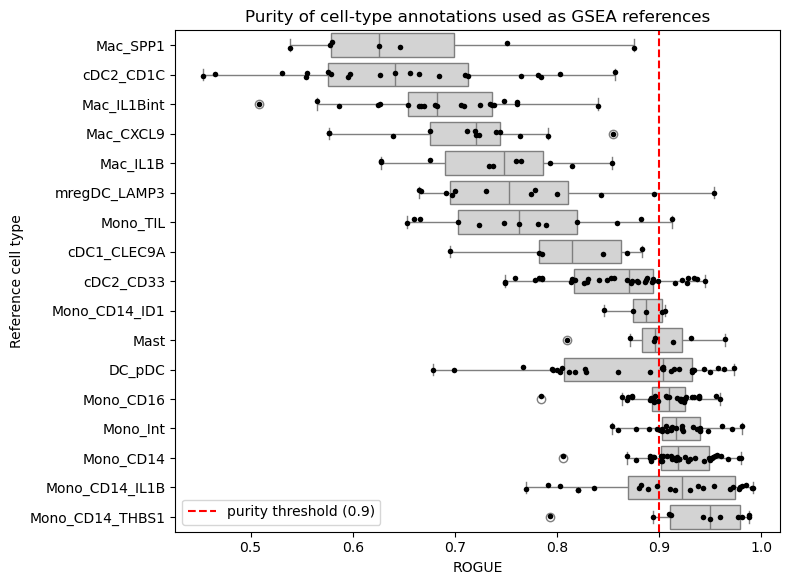

In [6]:
fig, ax = plt.subplots(figsize=(8, max(3, 0.35 * len(ct_summary))))
order = ct_summary.index
sns.boxplot(data=ct_long, y='cluster', x='ROGUE', order=order, color='lightgray', ax=ax)
sns.stripplot(data=ct_long, y='cluster', x='ROGUE', order=order, color='black', size=4, ax=ax)
ax.axvline(0.9, ls='--', color='red', label='purity threshold (0.9)')
ax.set_xlabel('ROGUE')
ax.set_ylabel('Reference cell type')
ax.set_title('Purity of cell-type annotations used as GSEA references')
ax.legend()
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/rogue_celltype_audit.png", dpi=150)
plt.show()